# Лабораторная 6. Семантическая сегментация

Семантическая сегментация — задача глубокого обучения, в которой каждому пикселю изображения присваивается метка класса. В отличие от обычной классификации (одна метка на картинку) или детекции (bounding box'ы), сегментация выдаёт попиксельную маску.

Архитектура сети под такую задачу обычно имеет три уровня: **энкодер** (сжимает картинку в латентное пространство, извлекая признаки), **латентное пространство** (бутылочное горлышко с самыми высокоуровневыми признаками) и **декодер** (восстанавливает разрешение обратно, выдавая маску). Для передачи мелких деталей из энкодера в декодер используются skip-connections.

В данной работе цель — получить mIoU > 0.6 на тестовой выборке. Используется **Semantic Drone Dataset**: 400 RGB-изображений 6000×4000 пикселей, 23 класса.

## Особенности пайплайна
1. **Обучение на случайных кропах 512×512** из оригинальных 6000×4000 — иначе редкие классы (люди, велосипеды) буквально исчезают при ресайзе
2. **Sliding window inference** на полном разрешении — модель видит мелкие объекты на тесте
3. **Глобальный mIoU** (аккумулятор по всему тест-сету), а не усреднение per-image — это стандартная метрика
4. **SegFormer-B2** с энкодером MiT-B2 — современная архитектура, лучше ловит границы
5. **CE + Dice + Lovász** — Lovász-Softmax напрямую оптимизирует mIoU

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms as T
import torchvision

import os, time, math
from PIL import Image
import cv2
from tqdm import tqdm

# если не установлено - раскомментируйте
# !pip install -q albumentations segmentation-models-pytorch timm
import albumentations as A
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss, LovaszLoss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print('SMP version:', smp.__version__)

c:\Users\Merrow\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


Using device: cuda
SMP version: 0.5.0


In [ ]:
IMAGE_PATH = 'dataset/semantic_drone_dataset/original_images/'
MASK_PATH  = 'dataset/semantic_drone_dataset/label_images_semantic/'
N_CLASSES = 23

def create_df():
    name = []
    for dirname, _, filenames in os.walk(IMAGE_PATH):
        for filename in filenames:
            name.append(filename.split('.')[0])
    return pd.DataFrame({'id': name}, index=np.arange(0, len(name)))

df = create_df()
print('Total Images:', len(df))

# сплит 80/12/8
ids = np.asarray(df['id'].to_numpy())
X_trainval, X_test = train_test_split(ids, test_size=0.08, random_state=19)
X_train, X_val     = train_test_split(X_trainval, test_size=0.13, random_state=19)
print(f'Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}')

Total Images: 400
Train: 320  Val: 48  Test: 32


Image: (4000, 6000, 3)  Mask: (4000, 6000)
Mask classes: [ 0  1  2  4  8 10 15 19 22]


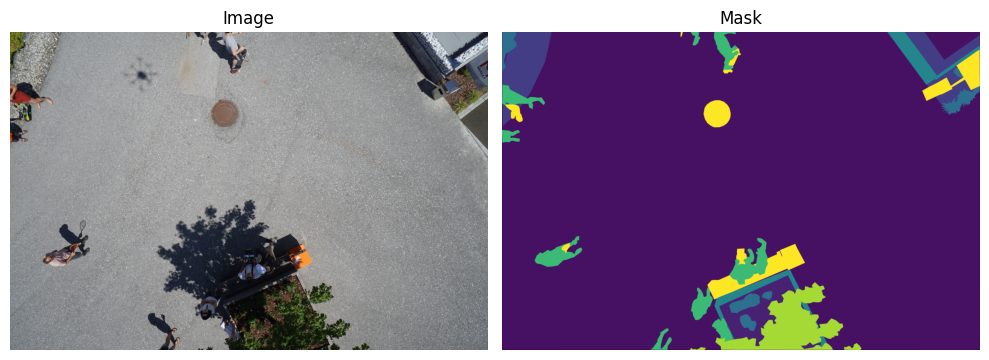

In [ ]:
sample_id = df['id'].iloc[0]
img = Image.open(IMAGE_PATH + sample_id + '.jpg')
mask = Image.open(MASK_PATH + sample_id + '.png')
print('Image:', np.asarray(img).shape, ' Mask:', np.asarray(mask).shape)
print('Mask classes:', np.unique(np.array(mask)))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(img); plt.title('Image'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(mask); plt.title('Mask'); plt.axis('off')
plt.tight_layout(); plt.show()

In [4]:
# частоты классов - нужны чтоб задать веса для редких
print('Computing class frequencies on train masks...')
class_counts = np.zeros(N_CLASSES, dtype=np.int64)
for img_id in X_train:
    m = cv2.imread(MASK_PATH + img_id + '.png', cv2.IMREAD_GRAYSCALE)
    vals, cnts = np.unique(m, return_counts=True)
    for v, c in zip(vals, cnts):
        if v < N_CLASSES:
            class_counts[v] += c

# 1/log(1.1+freq) - мягче чем 1/freq, иначе обучение рвёт
class_weights = np.where(
    class_counts > 0,
    1.0 / np.log(1.1 + class_counts / class_counts.sum()),
    0.0,
)
class_weights = np.clip(class_weights, 0.2, 5.0).astype(np.float32)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print('Class weights:', class_weights.cpu().numpy().round(3))

Computing class frequencies on train masks...
Class weights: [5.    2.53  5.    3.913 5.    5.    5.    5.    5.    5.    5.    5.
 5.    5.    5.    5.    5.    5.    5.    5.    5.    5.    5.   ]


In [5]:
class DroneDataset(Dataset):
    # рандомные кропы с оригинала 6000x4000 - так мелкие классы не теряются
    def __init__(self, img_path, mask_path, X, crop_size=512, augment=False, samples_per_image=20):
        self.img_path = img_path
        self.mask_path = mask_path
        self.X = X
        self.crop_size = crop_size
        self.augment = augment
        self.samples_per_image = samples_per_image
        self.mean = [0.485, 0.456, 0.406]
        self.std  = [0.229, 0.224, 0.225]

    def __len__(self):
        return len(self.X) * self.samples_per_image

    def __getitem__(self, idx):
        img_id = self.X[idx % len(self.X)]
        img = cv2.imread(self.img_path + img_id + '.jpg')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.mask_path + img_id + '.png', cv2.IMREAD_GRAYSCALE)
        H, W = mask.shape

        cs = self.crop_size
        if self.augment:
            # multiscale
            scale = np.random.uniform(0.5, 1.0)
            new_h, new_w = int(H * scale), int(W * scale)
            img_s = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
            mask_s = cv2.resize(mask, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
            y = np.random.randint(0, max(1, new_h - cs))
            x = np.random.randint(0, max(1, new_w - cs))
            img_crop = img_s[y:y+cs, x:x+cs]
            mask_crop = mask_s[y:y+cs, x:x+cs]
            # флипы
            if np.random.rand() < 0.5: img_crop, mask_crop = np.fliplr(img_crop).copy(), np.fliplr(mask_crop).copy()
            if np.random.rand() < 0.5: img_crop, mask_crop = np.flipud(img_crop).copy(), np.flipud(mask_crop).copy()
            # hsv джиттер - без него на дроне жёстко переобучается на цвет
            if np.random.rand() < 0.5:
                hsv = cv2.cvtColor(img_crop, cv2.COLOR_RGB2HSV)
                h = (hsv[..., 0].astype(int) + np.random.randint(-15, 15)) % 180
                s = np.clip(hsv[..., 1].astype(int) + np.random.randint(-30, 30), 0, 255)
                v = np.clip(hsv[..., 2].astype(int) + np.random.randint(-30, 30), 0, 255)
                hsv = np.stack([h, s, v], axis=-1).astype(np.uint8)
                img_crop = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
            # лёгкий шум
            if np.random.rand() < 0.3:
                img_crop = np.clip(img_crop.astype(np.float32) + np.random.normal(0, 5, img_crop.shape), 0, 255).astype(np.uint8)
        else:
            y = np.random.randint(0, max(1, H - cs))
            x = np.random.randint(0, max(1, W - cs))
            img_crop = img[y:y+cs, x:x+cs]
            mask_crop = mask[y:y+cs, x:x+cs]

        # норм
        img_crop = img_crop.astype(np.float32) / 255.0
        img_crop = (img_crop - np.array(self.mean)) / np.array(self.std)
        img_crop = torch.from_numpy(img_crop.transpose(2, 0, 1)).float()
        mask_crop = torch.from_numpy(mask_crop).long()
        return img_crop, mask_crop


class DroneTestDataset(Dataset):
    # для теста/вала - отдаём картинку целиком под sliding window
    def __init__(self, img_path, mask_path, X):
        self.img_path = img_path
        self.mask_path = mask_path
        self.X = X

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img_id = self.X[idx]
        img = cv2.imread(self.img_path + img_id + '.jpg')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.mask_path + img_id + '.png', cv2.IMREAD_GRAYSCALE)
        return img, mask

In [12]:
# B3 побольше B2, поэтому батч чуть уменьшил
CROP_SIZE = 384
BATCH_SIZE = 10
SAMPLES_PER_IMAGE = 8

train_set = DroneDataset(IMAGE_PATH, MASK_PATH, X_train,
                        crop_size=CROP_SIZE, augment=True,
                        samples_per_image=SAMPLES_PER_IMAGE)
val_set   = DroneTestDataset(IMAGE_PATH, MASK_PATH, X_val)
test_set  = DroneTestDataset(IMAGE_PATH, MASK_PATH, X_test)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True, drop_last=True)
print(f'Train: {len(train_set)} crops ({len(train_set)//len(X_train)} per image)')
print(f'Val: {len(val_set)} images, Test: {len(test_set)} images')

Train: 2560 crops (8 per image)
Val: 48 images, Test: 32 images


In [7]:
# B3 вместо B2 - с B2 не дотягивал до 0.6
model = smp.Segformer(
    encoder_name='mit_b3',
    encoder_weights='imagenet',
    in_channels=3,
    classes=N_CLASSES,
)
model.to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'SegFormer-B3: {n_params/1e6:.1f}M trainable params')

config.json:   0%|          | 0.00/135 [00:00<?, ?B/s]

c:\Users\Merrow\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Merrow\.cache\huggingface\hub\models--smp-hub--mit_b3.imagenet. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling

model.safetensors:   0%|          | 0.00/178M [00:00<?, ?B/s]

SegFormer-B3: 44.6M trainable params


In [8]:
def pixel_accuracy(output, mask):
    with torch.no_grad():
        output = torch.argmax(F.softmax(output, dim=1), dim=1)
        correct = torch.eq(output, mask).int()
        return float(correct.sum()) / float(correct.numel())

def mIoU(pred_logits, mask, smooth=1e-10, n_classes=N_CLASSES):
    # батчовый IoU по классам которые есть в маске
    with torch.no_grad():
        pred = torch.argmax(F.softmax(pred_logits, dim=1), dim=1)
        pred = pred.contiguous().view(-1)
        mask = mask.contiguous().view(-1)
        iou_per_class = []
        for c in range(n_classes):
            true_class = pred == c
            true_label = mask == c
            if true_label.long().sum().item() == 0:
                iou_per_class.append(np.nan)
            else:
                intersect = torch.logical_and(true_class, true_label).sum().float().item()
                union = torch.logical_or(true_class, true_label).sum().float().item()
                iou_per_class.append((intersect + smooth) / (union + smooth))
        return np.nanmean(iou_per_class)

class GlobalMIoU:
    # глобальный аккумулятор - правильный mIoU (сумма intersection / сумма union по всему сету)
    def __init__(self, n_classes=N_CLASSES):
        self.n_classes = n_classes
        self.intersect = np.zeros(n_classes, dtype=np.float64)
        self.union = np.zeros(n_classes, dtype=np.float64)

    def update(self, pred, target):
        for c in range(self.n_classes):
            pc = pred == c
            tc = target == c
            self.intersect[c] += np.logical_and(pc, tc).sum()
            self.union[c] += np.logical_or(pc, tc).sum()

    def compute(self):
        iou = np.where(self.union > 0,
                       self.intersect / np.maximum(self.union, 1e-10),
                       np.nan)
        return np.nanmean(iou), iou

In [9]:
def sliding_window_predict(model, img_np, crop_size=384, stride=256, n_classes=N_CLASSES,
                            mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225),
                            use_amp=True, tta=True):
    # sliding window с гауссом + TTA флипами
    model.eval()
    H, W, _ = img_np.shape

    pad_h = max(0, crop_size - H)
    pad_w = max(0, crop_size - W)
    if pad_h or pad_w:
        img_np = np.pad(img_np, ((0, pad_h), (0, pad_w), (0, 0)), mode='reflect')
        H, W, _ = img_np.shape

    # гаусс - центр кропа важнее краёв
    ys = np.arange(crop_size)
    g1d = np.exp(-((ys - crop_size / 2) ** 2) / (2 * (crop_size / 4) ** 2))
    gauss = np.outer(g1d, g1d).astype(np.float32)

    probs_sum = np.zeros((n_classes, H, W), dtype=np.float32)
    weight_sum = np.zeros((H, W), dtype=np.float32)

    img_norm = (img_np.astype(np.float32) / 255.0 - np.array(mean)) / np.array(std)

    y_positions = list(range(0, max(1, H - crop_size + 1), stride))
    x_positions = list(range(0, max(1, W - crop_size + 1), stride))
    if y_positions[-1] + crop_size < H: y_positions.append(H - crop_size)
    if x_positions[-1] + crop_size < W: x_positions.append(W - crop_size)

    # TTA: оригинал + 3 флипа, среднее по softmax
    flips = [None, 'h', 'v', 'hv'] if tta else [None]

    with torch.no_grad():
        for y in y_positions:
            for x in x_positions:
                crop = img_norm[y:y+crop_size, x:x+crop_size]  # HW3
                acc = None
                for f in flips:
                    if f is None:
                        c = crop
                    elif f == 'h':
                        c = crop[:, ::-1].copy()
                    elif f == 'v':
                        c = crop[::-1, :].copy()
                    else:
                        c = crop[::-1, ::-1].copy()
                    c_t = torch.from_numpy(c.transpose(2, 0, 1)).unsqueeze(0).float().to(device)
                    if use_amp:
                        with torch.amp.autocast('cuda'):
                            logits = model(c_t)
                    else:
                        logits = model(c_t)
                    p = F.softmax(logits.float(), dim=1).squeeze(0).cpu().numpy()  # CHW
                    # обратный флип - предикт вернул в исходную ориентацию
                    if f == 'h':
                        p = p[:, :, ::-1].copy()
                    elif f == 'v':
                        p = p[:, ::-1, :].copy()
                    elif f == 'hv':
                        p = p[:, ::-1, ::-1].copy()
                    acc = p if acc is None else acc + p
                acc = acc / len(flips)
                probs_sum[:, y:y+crop_size, x:x+crop_size] += acc * gauss[None]
                weight_sum[y:y+crop_size, x:x+crop_size] += gauss

    weight_sum = np.maximum(weight_sum, 1e-10)
    final_probs = probs_sum / weight_sum[None]
    final_mask = np.argmax(final_probs, axis=0)

    if pad_h or pad_w:
        final_mask = final_mask[:H - pad_h, :W - pad_w]
    return final_mask

In [10]:
def fit(epochs, model, train_loader, val_set, criterion_ce, criterion_dice, criterion_lov,
        optimizer, scheduler, use_lov=False, patience=10):
    # обычный train loop с AMP. Валидация - быстрая, 8 центральных кропов.
    # Полный sliding window только на финальном тесте, иначе вечность.
    torch.cuda.empty_cache()
    scaler = torch.amp.GradScaler('cuda')

    train_losses, val_ious = [], []
    best_miou, no_improve = 0.0, 0
    fit_time = time.time()

    # кропы для быстрой валидации - один раз, переиспользуем
    val_crops = []
    mean = [0.485, 0.456, 0.406]; std = [0.229, 0.224, 0.225]
    cs = 384
    for img_id in val_set.X[:8]:
        img = cv2.imread(val_set.img_path + img_id + '.jpg')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(val_set.mask_path + img_id + '.png', cv2.IMREAD_GRAYSCALE)
        H, W = mask.shape
        y = (H - cs) // 2; x = (W - cs) // 2
        img_c = img[y:y+cs, x:x+cs]
        mask_c = mask[y:y+cs, x:x+cs]
        img_n = (img_c.astype(np.float32)/255.0 - np.array(mean)) / np.array(std)
        val_crops.append((torch.from_numpy(img_n.transpose(2,0,1)).float(),
                          torch.from_numpy(mask_c).long()))

    for epoch in range(epochs):
        since = time.time()
        model.train()
        running_loss, running_iou, n_batches = 0.0, 0.0, 0

        # lovasz подключаю со второй трети - сначала пусть CE+Dice выучат базу
        epoch_use_lov = use_lov and epoch >= epochs // 3

        pbar = tqdm(train_loader, ncols=100, desc=f'E{epoch+1}/{epochs}')
        for img, mask in pbar:
            img = img.to(device, non_blocking=True)
            mask = mask.to(device, non_blocking=True)

            optimizer.zero_grad()
            with torch.amp.autocast('cuda'):
                logits = model(img)
                loss_ce = criterion_ce(logits, mask)
                loss_dice = criterion_dice(logits, mask)
                if epoch_use_lov:
                    loss_lov = criterion_lov(logits, mask)
                    loss = 0.4 * loss_ce + 0.3 * loss_dice + 0.3 * loss_lov
                else:
                    loss = 0.6 * loss_ce + 0.4 * loss_dice

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()
            running_iou += mIoU(logits, mask)
            n_batches += 1
            pbar.set_postfix({'loss': f'{running_loss/n_batches:.4f}',
                              'miou': f'{running_iou/n_batches:.4f}',
                              'lov': 'on' if epoch_use_lov else 'off'})

        scheduler.step()
        train_loss = running_loss / n_batches
        train_miou = running_iou / n_batches

        # быстрая валидация
        model.eval()
        val_metric = GlobalMIoU()
        with torch.no_grad():
            for img_t, mask_t in val_crops:
                img_t = img_t.unsqueeze(0).to(device)
                mask_t = mask_t.to(device)
                with torch.amp.autocast('cuda'):
                    logits = model(img_t)
                pred = torch.argmax(F.softmax(logits, dim=1), dim=1).squeeze(0).cpu().numpy()
                val_metric.update(pred, mask_t.cpu().numpy())
        val_miou, _ = val_metric.compute()

        train_losses.append(train_loss); val_ious.append(val_miou)

        if val_miou > best_miou:
            best_miou = val_miou
            no_improve = 0
            torch.save(model.state_dict(), 'best_model.pth')
            print(f'  -> new best val mIoU {best_miou:.4f}, saved')
        else:
            no_improve += 1

        print(f"Epoch {epoch+1}/{epochs}  train_loss={train_loss:.4f}  train_mIoU={train_miou:.4f}  "
              f"val_mIoU={val_miou:.4f}  lr={optimizer.param_groups[0]['lr']:.5f}  "
              f"time={(time.time()-since)/60:.2f}m")

        if no_improve >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

    model.load_state_dict(torch.load('best_model.pth', map_location=device))
    print(f'Loaded best, val mIoU = {best_miou:.4f}, total {(time.time()-fit_time)/60:.2f}m')
    return {'train_loss': train_losses, 'val_miou': val_ious}

In [13]:
EPOCHS = 50
MAX_LR = 1.5e-4   # B3 поосторожнее чем B2
WEIGHT_DECAY = 1e-4

criterion_ce   = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
criterion_dice = DiceLoss(mode='multiclass', classes=None, log_loss=False, from_logits=True)
criterion_lov  = LovaszLoss(mode='multiclass', from_logits=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=MAX_LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=MAX_LR, epochs=EPOCHS,
    steps_per_epoch=len(train_loader), pct_start=0.1, anneal_strategy='cos')

history = fit(EPOCHS, model, train_loader, val_set,
              criterion_ce, criterion_dice, criterion_lov,
              optimizer, scheduler, use_lov=True, patience=12)

E1/50: 100%|███████████████████| 256/256 [11:56<00:00,  2.80s/it, loss=1.6746, miou=0.1410, lov=off]


  -> new best val mIoU 0.1662, saved
Epoch 1/50  train_loss=1.6746  train_mIoU=0.1410  val_mIoU=0.1662  lr=0.00001  time=11.96m


E2/50: 100%|███████████████████| 256/256 [12:13<00:00,  2.86s/it, loss=1.0541, miou=0.3079, lov=off]


  -> new best val mIoU 0.2553, saved
Epoch 2/50  train_loss=1.0541  train_mIoU=0.3079  val_mIoU=0.2553  lr=0.00001  time=12.23m


E3/50: 100%|███████████████████| 256/256 [12:20<00:00,  2.89s/it, loss=0.8822, miou=0.3784, lov=off]


...

Epoch 38/50  train_loss=0.4810  train_mIoU=0.6003  val_mIoU=0.5377  lr=0.00001  time=11.93m


E39/50: 100%|███████████████████| 256/256 [11:55<00:00,  2.79s/it, loss=0.4893, miou=0.6003, lov=on]


Epoch 39/50  train_loss=0.4893  train_mIoU=0.6003  val_mIoU=0.6188  lr=0.00001  time=11.93m


E40/50: 100%|███████████████████| 256/256 [11:59<00:00,  2.81s/it, loss=0.4793, miou=0.6048, lov=on]


Epoch 40/50  train_loss=0.4793  train_mIoU=0.6048  val_mIoU=0.5237  lr=0.00001  time=11.99m
Early stopping at epoch 40
Loaded best, val mIoU = 0.6406, total 475.27m


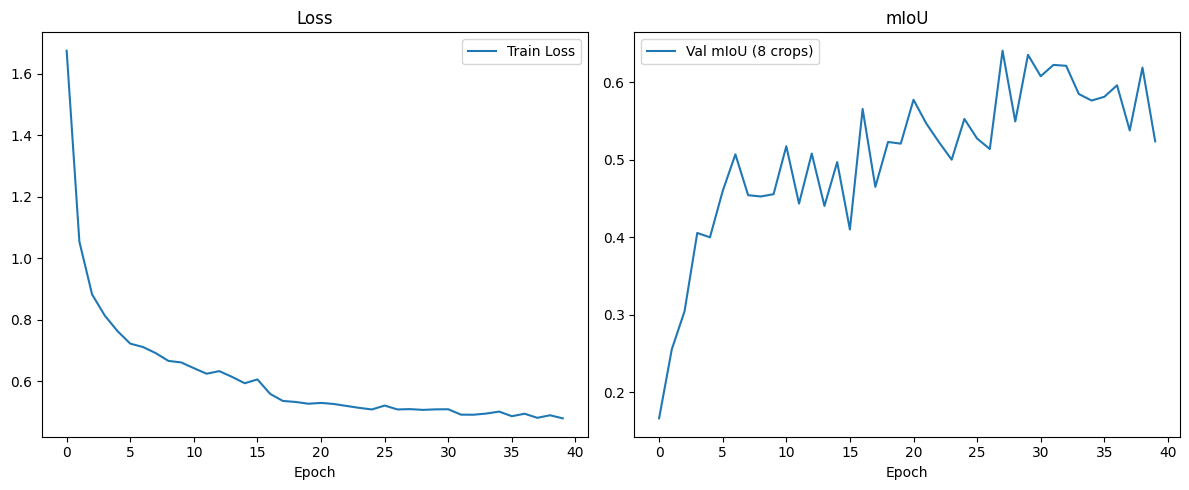

In [14]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.title('Loss'); plt.xlabel('Epoch'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history['val_miou'], label='Val mIoU (8 crops)')
plt.title('mIoU'); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout(); plt.show()

In [15]:
# грузим лучшую модель
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.to(device)
model.eval()
print('Loaded best_model.pth')

Loaded best_model.pth


In [16]:
test_metric = GlobalMIoU()
test_pixel_acc_sum, test_pixel_total = 0, 0

# TTA включена - чуть медленнее, но точнее
for i in tqdm(range(len(test_set)), desc='Test inference (TTA)'):
    img_np, mask_np = test_set[i]
    pred = sliding_window_predict(model, img_np, crop_size=384, stride=256, tta=True)
    test_metric.update(pred, mask_np)
    test_pixel_acc_sum += (pred == mask_np).sum()
    test_pixel_total += mask_np.size

test_miou, iou_per_class = test_metric.compute()
test_pixel_acc = test_pixel_acc_sum / test_pixel_total

print(f'\n=== FINAL TEST RESULTS ===')
print(f'Test mIoU (global, TTA): {test_miou:.4f}')
print(f'Test Pixel Accuracy: {test_pixel_acc:.4f}')
print(f'\nIoU per class:')
for c, iou in enumerate(iou_per_class):
    if not np.isnan(iou):
        print(f'  class {c:2d}: {iou:.4f}')

Test inference (TTA): 100%|██████████| 32/32 [37:10<00:00, 69.71s/it]


=== FINAL TEST RESULTS ===
Test mIoU (global, TTA): 0.6128
Test Pixel Accuracy: 0.9124

IoU per class:
  class  0: 0.0000
  class  1: 0.9468
  class  2: 0.6396
  class  3: 0.9330
  class  4: 0.8617
  class  5: 0.8841
  class  6: 0.4993
  class  7: 0.9573
  class  8: 0.5571
  class  9: 0.9523
  class 10: 0.5364
  class 11: 0.3465
  class 13: 0.4616
  class 14: 0.0000
  class 15: 0.8181
  class 16: 0.0000
  class 17: 0.9189
  class 18: 0.6614
  class 19: 0.5776
  class 20: 0.5350
  class 21: 0.8601
  class 22: 0.5358


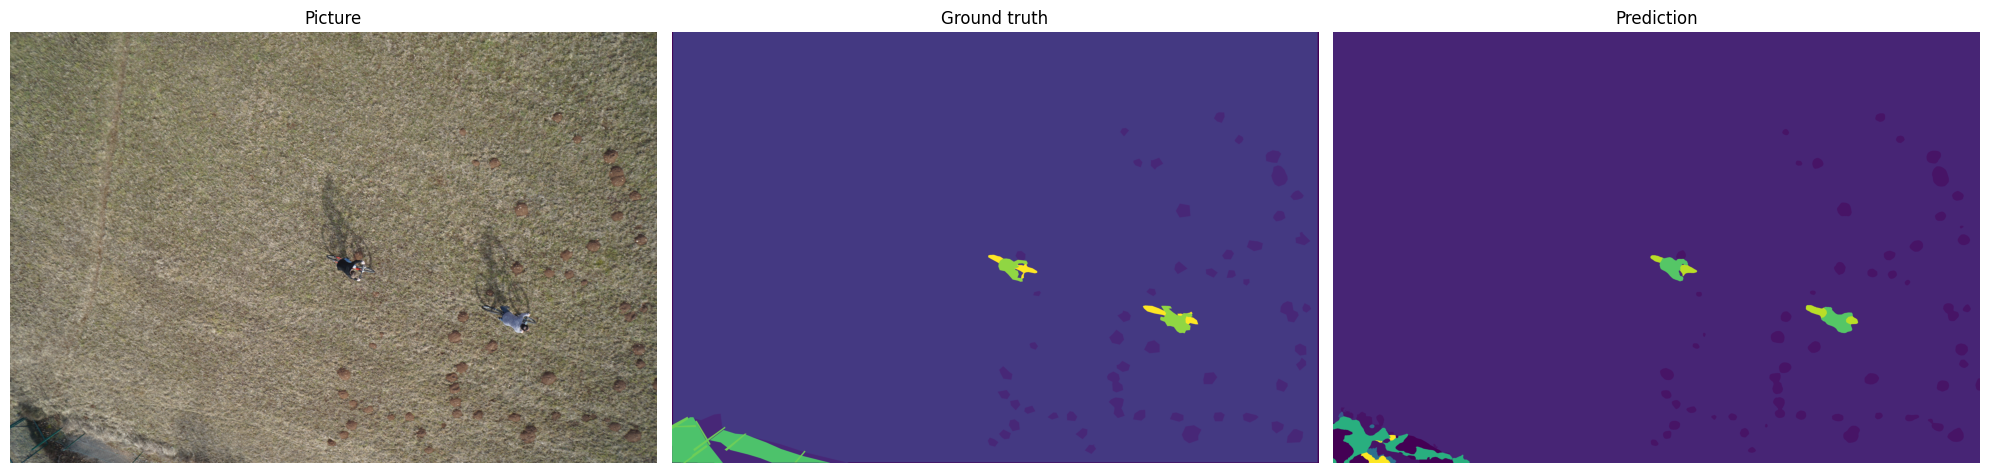

In [17]:
test_idx = 0
img_np, mask_np = test_set[test_idx]
pred = sliding_window_predict(model, img_np, crop_size=384, stride=256, tta=True)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 7))
ax1.imshow(img_np); ax1.set_title('Picture'); ax1.axis('off')
ax2.imshow(mask_np); ax2.set_title('Ground truth'); ax2.axis('off')
ax3.imshow(pred); ax3.set_title('Prediction'); ax3.axis('off')
plt.tight_layout(); plt.show()

## Ответы на вопросы к защите

**1. Что такое семантическая сегментация?**
Это задача компьютерного зрения, в которой каждому пикселю изображения присваивается метка класса. В отличие от обычной классификации (одна метка на всю картинку) или детекции (bounding box'ы), сегментация выдаёт попиксельную маску того же размера, что и вход.

**2. Особенности архитектуры нейронных сетей для семантической сегментации?**
Классический паттерн — encoder-decoder. Энкодер (обычно CNN или transformer) сжимает картинку в латентное представление, извлекая признаки. Декодер восстанавливает разрешение обратно, выдавая маску. Между ними делаются skip-connections (как в U-Net), чтобы передать мелкие детали из энкодера в декодер — без них сеть теряет границы объектов. В данной работе используется SegFormer: энкодер MiT-B2 (иерархический transformer) + простой MLP-декодер. Другие популярные архитектуры: U-Net, FPN, DeepLabV3+, Mask2Former.

**3. Как работает свёртка?**
Conv2d берёт маленький фильтр (kernel, обычно 3×3 или 5×5) и проходит им по картинке. На каждой позиции выполняется поэлементное умножение значений фильтра на соответствующие пиксели и сумма — это и есть одно значение выходной карты признаков. Параметры: kernel_size, stride (шаг сдвига), padding (дополнение нулями по краям). При stride=1 и padding=kernel_size//2 разрешение сохраняется; при stride>1 — уменьшается. Веса фильтров учатся во время обучения, сеть сама выучивает нужные признаки (границы, текстуры и т.д.).

**4. Можно ли использовать трансформерные архитектуры для семантической сегментации и в чём ограничения?**
Да, в этой работе как раз и используется SegFormer — transformer-архитектура. Ограничения: (1) attention имеет квадратичную сложность от числа токенов, поэтому на больших картинках нужно патчить или иерархически уменьшать разрешение (что и делает MiT — Hierarchical Transformer); (2) трансформеры требуют много данных и предобучения — с нуля на малом датасете часто проигрывают CNN; (3) тяжелее и дольше обучаются. На практике их ставят, когда есть большой датасет и важна точность, либо берут уже предобученные на гигантских корпусах (ImageNet-1k/22k).

**5. Какая метрика используется и как она вычисляется?**
Основная метрика — **mIoU** (mean Intersection over Union). Корректный способ вычисления — **глобальный аккумулятор**: для каждого класса c по всему тестовому сету считаем `Σ intersection` (число пикселей, где и pred, и GT = c) и `Σ union` (число пикселей, где pred или GT = c). IoU_c = intersection / union. Финальный mIoU = mean(IoU_c) по классам, которые присутствуют в датасете. Дополнительно считают pixel accuracy — долю правильно классифицированных пикселей, но она нечувствительна к дисбалансу классов (легко завышается доминирующим фоном). В данной реализации используется класс `GlobalMIoU`, аккумулирующий intersection/union по всем тест-картинкам.